# Titanic EDA — Үй тапсырмасы (Jupyter Notebook)

**Мақсат:** Толық EDA (Basic → Advanced) — әр қадамға қазақша түсініктеме, графиктер және нәтижелер.

Дереккөзі: `https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv`

---

In [1]:
# Импорттар
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde

# Деректерді жүктеу
# Ескерту: интернет бар болған жағдайда көрсетілген URL-дан жүктеледі
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

df = pd.read_csv(url)

# Жүктелген деректің алғашқы 5 жолын көрсету
# (әрқашан деректі қарап алған дұрыс)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# 1. Basic — Деректерге шолу
# 1.1. Shape және Columns
print('Shape (қатарлар, бағандар):', df.shape)
print('\nColumns:')
print(df.columns.tolist())

# 1.2. Әр баған бойынша бос мәндер саны
print('\nNull count by column:')
print(df.isnull().sum())

Shape (қатарлар, бағандар): (891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Null count by column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [3]:
# 1.3. age және fare бағандарының негізгі статистикасы
for col in ['Age', 'Fare']:
    print(f"--- {col} ---")
    print('mean:', df[col].mean())
    print('min:', df[col].min())
    print('max:', df[col].max())
    print('std:', df[col].std())
    print()

--- Age ---
mean: 29.69911764705882
min: 0.42
max: 80.0
std: 14.526497332334044

--- Fare ---
mean: 32.204207968574636
min: 0.0
max: 512.3292
std: 49.693428597180905



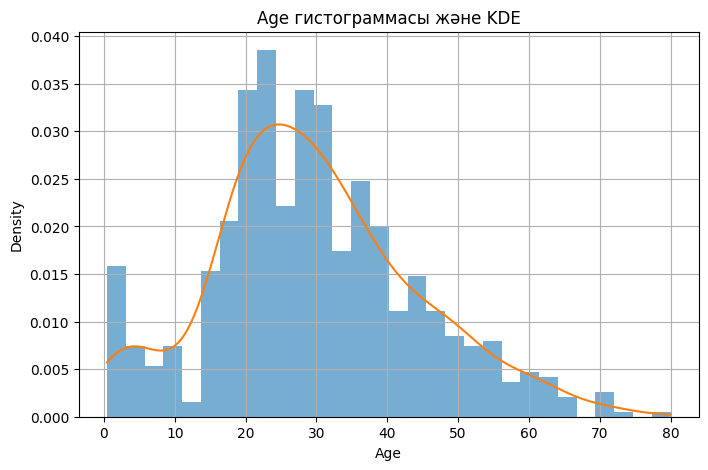

In [4]:
# 1.4. Age гистограммасы + KDE
# pandas/Matplotlib арқылы гистограмма және SciPy арқылы KDE қосу
ages = df['Age'].dropna()

plt.figure(figsize=(8,5))
# Гистограмма
plt.hist(ages, bins=30, density=True, alpha=0.6)
# KDE қисығын есептеу
kde = gaussian_kde(ages)
xs = np.linspace(ages.min(), ages.max(), 200)
plt.plot(xs, kde(xs))
plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Age гистограммасы және KDE')
plt.grid(True)
plt.show()

/tmp/ipython-input-3851075668.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(fare_groups, labels=labels, showfliers=True)


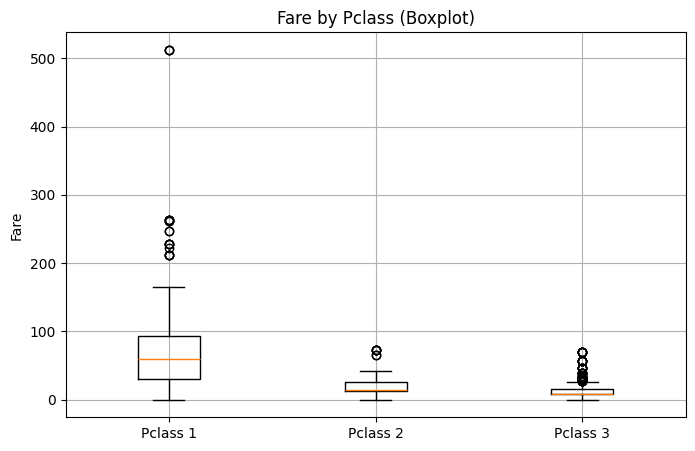

Pclass 1: outliers count = 20
Pclass 2: outliers count = 7
Pclass 3: outliers count = 52


In [5]:
# 2.1 Boxplot: fare бойынша pclass тобы
# Алдымен әр pclass үшін fare тізімдерін құрамыз
fare_groups = [df[df['Pclass']==c]['Fare'].dropna().values for c in sorted(df['Pclass'].unique())]
labels = [f'Pclass {c}' for c in sorted(df['Pclass'].unique())]

plt.figure(figsize=(8,5))
plt.boxplot(fare_groups, labels=labels, showfliers=True)
plt.ylabel('Fare')
plt.title('Fare by Pclass (Boxplot)')
plt.grid(True)
plt.show()

# Ауытқуларды анықтау: жекелеген кластар үшін IQR арқылы қарауға болады
for c in sorted(df['Pclass'].unique()):
    fares = df[df['Pclass']==c]['Fare'].dropna()
    q1 = fares.quantile(0.25)
    q3 = fares.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = fares[(fares < lower) | (fares > upper)]
    print(f'Pclass {c}: outliers count =', outliers.count())

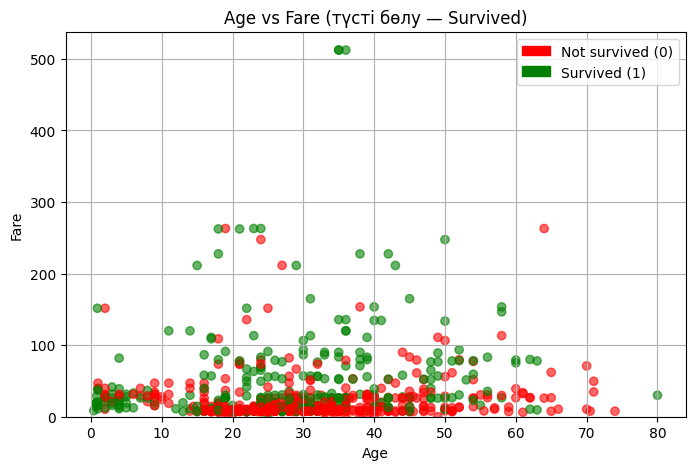

In [6]:
# 2.2 Scatter: Age vs Fare, survived бойынша түске бөлу
# survived=0 және survived=1 үшін әр түрлі маркерлер қойып шығаруға болады
plt.figure(figsize=(8,5))
# Бос age мәндерін алып тастаймыз
sub = df.dropna(subset=['Age'])
# Түстер үшін survived бағанын пайдаланамыз
colors = sub['Survived'].map({0: 'red', 1: 'green'})
plt.scatter(sub['Age'], sub['Fare'], c=colors, alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare (түсті бөлу — Survived)')
plt.grid(True)
# Легенда жасау
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', label='Not survived (0)')
green_patch = mpatches.Patch(color='green', label='Survived (1)')
plt.legend(handles=[red_patch, green_patch])
plt.ylim(bottom=0)
plt.show()

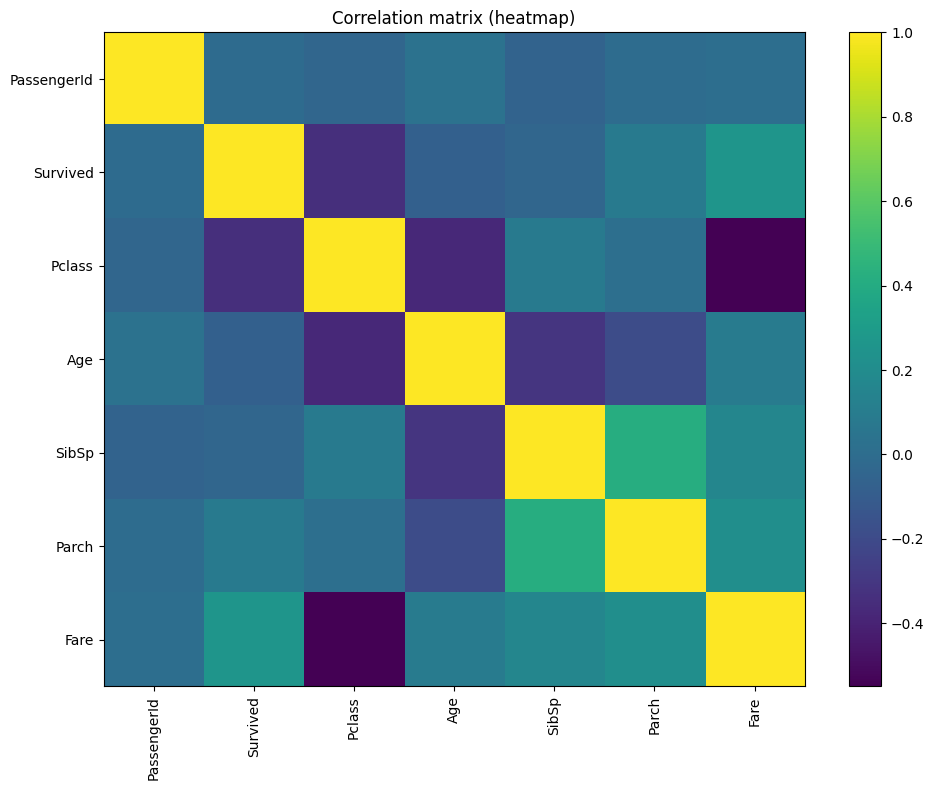


Top correlations (including self-correlations):
PassengerId  PassengerId    1.000000
Survived     Survived       1.000000
Pclass       Pclass         1.000000
SibSp        SibSp          1.000000
Age          Age            1.000000
Parch        Parch          1.000000
Fare         Fare           1.000000
Parch        SibSp          0.414838
SibSp        Parch          0.414838
Survived     Fare           0.257307
dtype: float64


In [7]:
# 2.3 Heatmap: сандық бағандардың корреляциясы
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, interpolation='nearest', aspect='auto')
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title('Correlation matrix (heatmap)')
plt.tight_layout()
plt.show()

# Корреляция матрицасының басынан бірнеше жоғары мәндерді көрсете аламыз
corr_unstacked = corr.unstack().sort_values(ascending=False)
print('\nTop correlations (including self-correlations):')
print(corr_unstacked.head(10))

In [8]:
# 2.4 Бос мәндерді толтыру (imputation)
# Age → медиана
age_median = df['Age'].median()
df['Age_filled'] = df['Age'].fillna(age_median)
print('Age медианасы:', age_median)

# Embarked → mode
embarked_mode = df['Embarked'].mode()[0]
df['Embarked_filled'] = df['Embarked'].fillna(embarked_mode)
print('Embarked ең жиі мәні (mode):', embarked_mode)

# Нәтижені тексеру
print('\nNulls after imputation:')
print(df[['Age_filled','Embarked_filled']].isnull().sum())

Age медианасы: 28.0
Embarked ең жиі мәні (mode): S

Nulls after imputation:
Age_filled         0
Embarked_filled    0
dtype: int64


In [9]:
# 3.1 Категориялық белгілерді кодтау
# sex → Label Encoding (male=0, female=1)
df['Sex_encoded'] = df['Sex'].map({'male':0, 'female':1})

# embarked → One-Hot Encoding
embarked_dummies = pd.get_dummies(df['Embarked_filled'], prefix='Embarked')
df = pd.concat([df, embarked_dummies], axis=1)

# Тексеру
print(df[['Sex','Sex_encoded']].head())
print('\nEmbarked dummies columns:', [c for c in df.columns if c.startswith('Embarked_')])

      Sex  Sex_encoded
0    male            0
1  female            1
2  female            1
3  female            1
4    male            0

Embarked dummies columns: ['Embarked_filled', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


In [10]:
# 3.2 Feature Engineering
# family_size = SibSp + Parch + 1
# Ескерту: кішкентай әріппен баған аттарын қоспай, бастапқы бағандар үлкен әріппен сақталса да есептейміз
df['Family_size'] = df['SibSp'] + df['Parch'] + 1

# age_group анықтау
def age_group(age):
    if age <= 12:
        return 'child'
    elif age <= 18:
        return 'teen'
    elif age <= 60:
        return 'adult'
    else:
        return 'senior'

# Age_filled бағанын пайдаланып топтау
df['Age_group'] = df['Age_filled'].apply(age_group)

# Нәтижелер
print(df[['Age_filled','Age_group']].head(10))
print('\nFamily_size sample:')
print(df[['SibSp','Parch','Family_size']].head())

   Age_filled Age_group
0        22.0     adult
1        38.0     adult
2        26.0     adult
3        35.0     adult
4        35.0     adult
5        28.0     adult
6        54.0     adult
7         2.0     child
8        27.0     adult
9        14.0      teen

Family_size sample:
   SibSp  Parch  Family_size
0      1      0            2
1      1      0            2
2      0      0            1
3      1      0            2
4      0      0            1


In [11]:
# 3.3 Масштабтау: StandardScaler қолдану
scaler = StandardScaler()
# Масштабтауға Age_filled және Fare бағандарын пайдаланамыз
scaled = scaler.fit_transform(df[['Age_filled','Fare']].fillna(0))

df['Age_scaled'] = scaled[:,0]
df['Fare_scaled'] = scaled[:,1]

# Бастапқы және масштабталған бірінші бірнеше жазбаларды салыстыру
df[['Age_filled','Age_scaled','Fare','Fare_scaled']].head()

,Age_filled,Age_scaled,Fare,Fare_scaled
0,22.0,-0.565736,7.2500,-0.502445
1,38.0,0.663861,71.2833,0.786845
2,26.0,-0.258337,7.9250,-0.488854
3,35.0,0.433312,53.1000,0.420730
4,35.0,0.433312,8.0500,-0.486337


Fare IQR: 23.0896
Lower bound: -26.724
Upper bound: 65.6344
Outliers count: 116


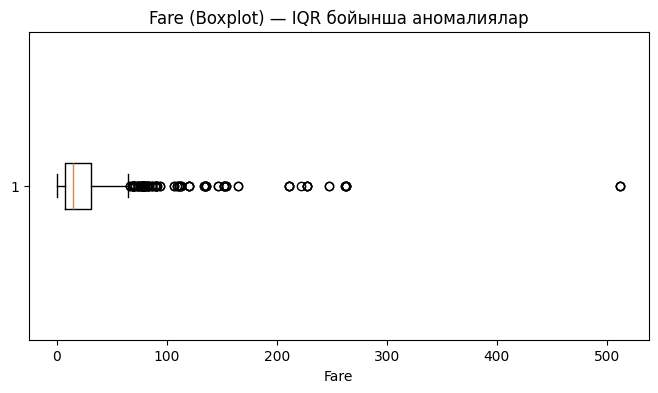

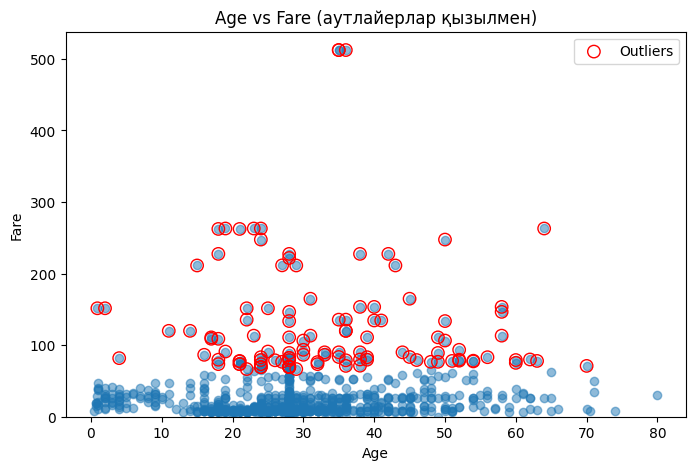

In [12]:
# 3.4 Ауытқуларды анықтау: Fare бойынша IQR
fare = df['Fare'].dropna()
q1 = fare.quantile(0.25)
q3 = fare.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)]
print('Fare IQR:', iqr)
print('Lower bound:', lower)
print('Upper bound:', upper)
print('Outliers count:', outliers.shape[0])

# Outliers-ты Boxplot арқылы көрсету
plt.figure(figsize=(8,4))
plt.boxplot(fare, vert=False, showfliers=True)
plt.title('Fare (Boxplot) — IQR бойынша аномалиялар')
plt.xlabel('Fare')
plt.show()

# Outliers-ты Age vs Fare scatter-та бөлектеп көрсету
plt.figure(figsize=(8,5))
plt.scatter(df['Age_filled'], df['Fare'], alpha=0.5)
plt.scatter(outliers['Age_filled'], outliers['Fare'], facecolors='none', edgecolors='r', s=80, label='Outliers')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare (аутлайерлар қызылмен)')
plt.legend()
plt.ylim(bottom=0)
plt.show()

## EDA Қорытындысы

**Негізгі қорытындылар:**

- Дерек `shape` және `columns` арқылы толық шолынды; маңызды бағандар: `Survived`, `Pclass`, `Name`, `Sex`, `Age`, `SibSp`, `Parch`, `Ticket`, `Fare`, `Cabin`, `Embarked`.
- Бос мәндер: `Age` және `Cabin` едәуір бос ұяшықтарға ие; `Embarked` кішкене бос ұяшықтар бар. Age медианамен, Embarked mode-пен толтырылды.
- `Age` және `Fare` статистикасы көрсетілді (mean, min, max, std).
- Boxplot арқылы `Fare` бағасының `Pclass` бойынша айырмашылықтары визуалданды; әр класта аномалия бар екені анықталды.
- Scatter plot — `Age` пен `Fare` арасындағы байланыс және `Survived` бойынша айырмашылықтар қаралды.
- Корреляция матрицасы есептеліп, визуалданды (heatmap). Бұл feature selection үшін пайдалы.
- `Sex` label encoding-ке, `Embarked` one-hot encoding-ке ауыстырылды.
- Feature engineering: `Family_size` және `Age_group` қосылды.
- `Age` және `Fare` StandardScaler арқылы масштабталды.
- `Fare` бойынша IQR әдісімен аутлайерлар анықталды және визуалданды.

Егер қажет болса, осы notebook-ты ары қарай модельдеу (classification) үшін дайындап, train/test split, feature selection және бастапқы модельдерді қоса аламын.
